# thumbLib Examples

Demonstrates all thumbLib output types: single thumbnails, animated GIFs, filmstrips, and multi-feature grids — with thematic and continuous data, dark and light themes, legend options, and CRS/projection control.

## Setup

In [ ]:
import geeViz.geeView as gv
import geeViz.getImagesLib as gil
from geeViz.outputLib import thumbs as tl
import geeViz.getSummaryAreasLib as sal
from IPython.display import Image, display, HTML
import os

ee = gv.ee

# Output directory for saved files
output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "outputs", "thumbLib_examples")
os.makedirs(output_dir, exist_ok=True)
print(f"Output dir: {output_dir}")

## Define Study Area, Projection, and Datasets

In [2]:
# Study area — Yellowstone National Park boundary
yellowstone_point = ee.Geometry.Point([-110.5, 44.6])
study_area = sal.getProtectedAreas(yellowstone_point).filter(
    ee.Filter.eq("DESIG", "National Park")
)

# UTM projection for this location
crs = gil.getUTMEpsg(yellowstone_point)
proj_scale = 30
print(f"CRS: {crs}, Scale: {proj_scale}m")

startYear = 2020
endYear = 2024
startJulian = 152
endJulian = 273

# Thematic dataset — LCMS Land Cover
lcms = (
    ee.ImageCollection("USFS/GTAC/LCMS/v2024-10")
    .select(["Land_Cover"])
)
lcms_single = lcms.filter(ee.Filter.calendarRange(2024, 2024, "year"))

# Continuous dataset — Sentinel-2 NDVI annual composites
s2 = gil.superSimpleGetS2(
        study_area.geometry().bounds(500), f"{startYear}-01-01", f"{endYear}-12-31",
        startJulian, endJulian,
    )
  


def annualComposite(yr, imgs):
    yr = ee.Number(yr)
    yrImgs = imgs.filter(ee.Filter.calendarRange(yr, yr, "year"))
    props = yrImgs.first().toDictionary()
    return yrImgs.median().set(props).set("system:time_start", ee.Date.fromYMD(yr, 6, 1))


s2Composites = ee.ImageCollection(
    ee.List.sequence(startYear, endYear).map(lambda yr: annualComposite(yr, s2))
)
s2Single = annualComposite(2024,s2)

print("Setup complete")

CRS: EPSG:32612, Scale: 30m
Setup complete


## 1. auto_viz — Automatic Visualization Detection

In [3]:
# Thematic auto-viz
thematic_viz = tl.auto_viz(lcms)
print("Thematic viz:", {k: v if k != "palette" else f"[{len(v)} colors]" for k, v in thematic_viz.items()})

# Continuous auto-viz
continuous_viz = gil.vizParamsFalse10k
print("Continuous viz:", continuous_viz)

Thematic viz: {'bands': ['Land_Cover'], 'min': 1, 'max': 15, 'palette': '[15 colors]'}
Continuous viz: {'min': 500.0, 'max': [5000.0, 6000.0, 6000.0], 'bands': 'swir1,nir,red', 'gamma': 1.6}


## 2. Single Thumbnails — `generate_thumbs()`

### Thematic (LCMS Land Cover)

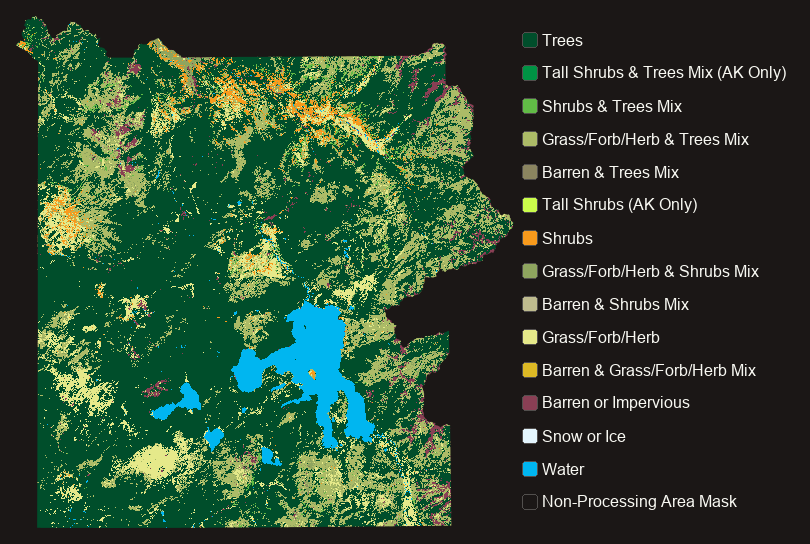

Thematic | Dark | Legend ON | UTM projection


In [22]:
# Thematic thumbnail — dark theme, with legend, UTM projection
result = tl.generate_thumbs(
    lcms_single, study_area,
    dimensions=512,
    burn_in_legend=True,
    bg_color="#1b1716",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "thumb_thematic_dark.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Thematic | Dark | Legend ON | UTM projection")

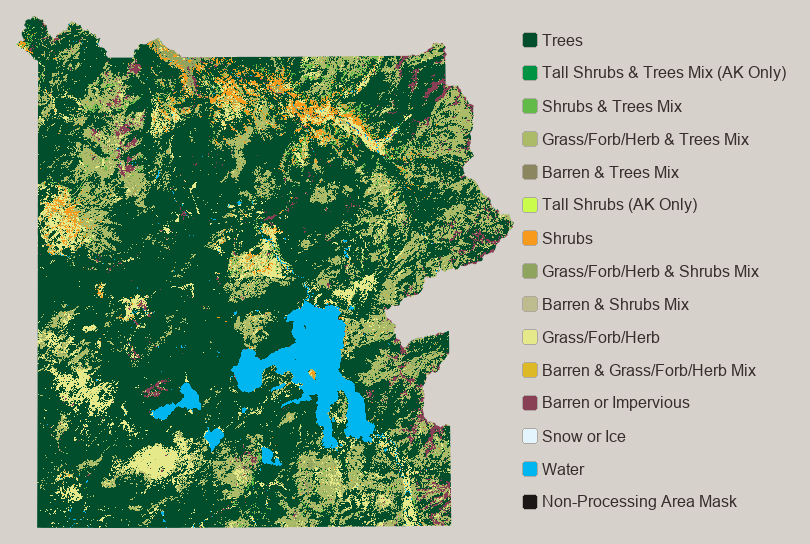

Thematic | Light | Legend ON


In [20]:
# Thematic thumbnail — light theme, with legend
result = tl.generate_thumbs(
    lcms_single, study_area,
    dimensions=512,
    burn_in_legend=True,
    bg_color="#d6d1ca",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "thumb_thematic_light.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Thematic | Light | Legend ON")

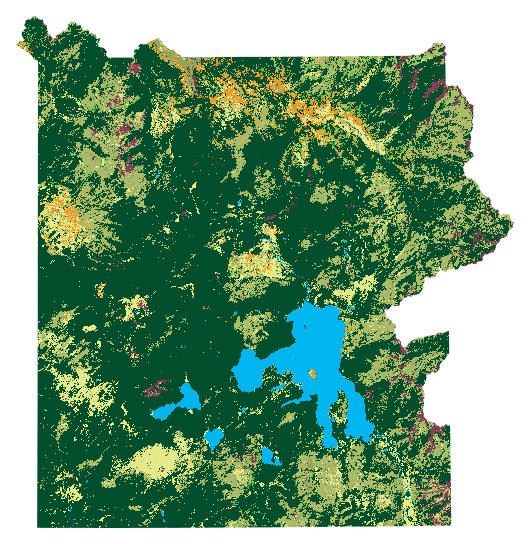

Thematic | No legend


In [25]:
# Thematic thumbnail — no legend
result = tl.generate_thumbs(
    lcms_single, study_area,
    dimensions=512,
    burn_in_legend=False,
    bg_color="#FFF",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "thumb_thematic_no_legend.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Thematic | No legend")

### Continuous (Sentinel-2)

In [ ]:
### Continuous (Sentinel-2)
result = tl.generate_thumbs(
    s2Single, study_area,
    viz_params=continuous_viz,
    dimensions=512,
    bg_color="black",
    crs=crs, scale=300,
    output_path=os.path.join(output_dir, "thumb_continuous_dark.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Continuous | Dark | UTM projection")

In [ ]:
# Continuous thumbnail — light background
result = tl.generate_thumbs(
    s2Single, study_area,
    viz_params=continuous_viz,
    dimensions=512,
    bg_color="#EEE",
    crs=crs, scale=300,
    output_path=os.path.join(output_dir, "thumb_continuous_light.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Continuous | Light")

## 3. Animated GIFs — `generate_gif()`

### Thematic GIF

In [ ]:
# Thematic GIF — dark, with date + legend, UTM projection
result = tl.generate_gif(
    lcms, study_area,
    dimensions=400,
    fps=3,
    burn_in_date=True,
    date_format="YYYY",
    burn_in_legend=True,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "gif_thematic_dark.gif"),
)
display(Image(data=result["gif_bytes"]))
print("Thematic GIF | Dark | Date + Legend | UTM")

In [ ]:
# Thematic GIF — light, with date + legend
result = tl.generate_gif(
    lcms, study_area,
    dimensions=400,
    fps=3,
    burn_in_date=True,
    date_format="YYYY",
    burn_in_legend=True,
    bg_color="white",
    date_color="black",
    date_outline_color="white",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "gif_thematic_light.gif"),
)
display(Image(data=result["gif_bytes"]))
print("Thematic GIF | Light | Date + Legend")

In [ ]:
# Thematic GIF — no date, no legend
result = tl.generate_gif(
    lcms, study_area,
    dimensions=400,
    fps=3,
    burn_in_date=False,
    burn_in_legend=False,
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "gif_thematic_plain.gif"),
)
display(Image(data=result["gif_bytes"]))
print("Thematic GIF | No date | No legend")

### Continuous GIF

In [ ]:
# Continuous GIF — with date labels, UTM projection
result = tl.generate_gif(
    s2Composites, study_area,
    viz_params=continuous_viz,
    dimensions=400,
    fps=2,
    burn_in_date=True,
    date_format="YYYY",
    bg_color="black",
    crs=crs, scale=30000,
    output_path=os.path.join(output_dir, "gif_continuous_dark.gif"),
)
display(Image(data=result["gif_bytes"]))
print("Continuous GIF | Dark | Date ON | UTM")

In [ ]:
# Continuous GIF — no date
result = tl.generate_gif(
    s2Composites, study_area,
    viz_params=continuous_viz,
    dimensions=400,
    fps=2,
    burn_in_date=False,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "gif_continuous_plain.gif"),
)
display(Image(data=result["gif_bytes"]))
print("Continuous GIF | No date | No legend")

## 4. Filmstrip Grid — `generate_filmstrip()`

### Thematic Filmstrip

In [ ]:
# Thematic filmstrip — dark, 3 columns, with legend, UTM projection
result = tl.generate_filmstrip(
    lcms, study_area,
    dimensions=300,
    columns=3,
    date_format="YYYY",
    burn_in_legend=True,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "filmstrip_thematic_dark.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Thematic Filmstrip | Dark | 3 cols | Legend | UTM")

In [ ]:
# Thematic filmstrip — light, 5 columns, with legend
result = tl.generate_filmstrip(
    lcms, study_area,
    dimensions=200,
    columns=5,
    date_format="YYYY",
    burn_in_legend=True,
    bg_color="#272822",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "filmstrip_thematic_light.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Thematic Filmstrip | Light | 5 cols | Legend")

In [ ]:
# Thematic filmstrip — no legend
result = tl.generate_filmstrip(
    lcms, study_area,
    dimensions=300,
    columns=3,
    burn_in_legend=False,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "filmstrip_thematic_no_legend.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Thematic Filmstrip | No legend")

### Continuous Filmstrip

In [ ]:
# Continuous filmstrip — dark, UTM projection
result = tl.generate_filmstrip(
    s2Composites, study_area,
    viz_params=ndvi_viz,
    dimensions=300,
    columns=3,
    date_format="YYYY",
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "filmstrip_continuous_dark.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Continuous Filmstrip | Dark | UTM")

## 5. Multi-Feature Grid — `generate_thumbs()` with `feature_label`

In [ ]:
# Define multiple study areas as a FeatureCollection
features = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-110.5, 44.6]).buffer(10000), {"name": "Yellowstone NW"}),
    ee.Feature(ee.Geometry.Point([-110.3, 44.5]).buffer(10000), {"name": "Yellowstone NE"}),
    ee.Feature(ee.Geometry.Point([-110.5, 44.4]).buffer(10000), {"name": "Yellowstone SW"}),
    ee.Feature(ee.Geometry.Point([-110.3, 44.4]).buffer(10000), {"name": "Yellowstone SE"}),
])

# Multi-feature grid — thematic, dark, with legend, UTM projection
result = tl.generate_thumbs(
    lcms_single, features,
    dimensions=512,
    feature_label="name",
    columns=2,
    thumb_width=300,
    burn_in_legend=True,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "grid_thematic_dark.png"),
)
display(Image(data=result["thumb_bytes"]))
print(f"Multi-feature grid | Dark | Legend | UTM | is_grid={result.get('is_grid')}")

In [ ]:
# Multi-feature grid — thematic, light
result = tl.generate_thumbs(
    lcms_single, features,
    dimensions=512,
    feature_label="name",
    columns=2,
    thumb_width=300,
    burn_in_legend=True,
    bg_color="white",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "grid_thematic_light.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Multi-feature grid | Light | Legend")

## 6. Legend Scale — Adjusting Legend Size

In [ ]:
# Small legend (0.5x)
result = tl.generate_thumbs(
    lcms_single, study_area,
    dimensions=512,
    burn_in_legend=True,
    legend_scale=0.5,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "thumb_legend_small.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Legend scale = 0.5")

In [ ]:
# Large legend (1.5x)
result = tl.generate_thumbs(
    lcms_single, study_area,
    dimensions=512,
    burn_in_legend=True,
    legend_scale=1.5,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "thumb_legend_large.png"),
)
display(Image(data=result["thumb_bytes"]))
print("Legend scale = 1.5")

## 7. GIF Date Format Options

In [ ]:
# Different date format — "MMM YYYY" style labels
result = tl.generate_gif(
    lcms.filter(ee.Filter.calendarRange(2020, 2024, "year")),
    study_area,
    dimensions=300,
    fps=2,
    burn_in_date=True,
    date_format="MMM YYYY",
    date_position="lower-right",
    burn_in_legend=True,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "gif_date_format_mmm_yyyy.gif"),
)
display(Image(data=result["gif_bytes"]))
print("GIF | date_format='MMM YYYY' | position=lower-right")

## 8. Projection Comparison — With vs Without CRS

In [ ]:
# Without CRS — default projection (may warp near edges)
result_no_crs = tl.generate_thumbs(
    lcms_single, study_area,
    dimensions=400,
    burn_in_legend=True,
    bg_color="black",
    output_path=os.path.join(output_dir, "thumb_no_crs.png"),
)
print("Without CRS:")
display(Image(data=result_no_crs["thumb_bytes"]))

# With UTM CRS — proper local projection
result_with_crs = tl.generate_thumbs(
    lcms_single, study_area,
    dimensions=400,
    burn_in_legend=True,
    bg_color="black",
    crs=crs, scale=proj_scale,
    output_path=os.path.join(output_dir, "thumb_with_crs.png"),
)
print(f"\nWith CRS ({crs} @ {proj_scale}m):")
display(Image(data=result_with_crs["thumb_bytes"]))

In [ ]:
# getUTMEpsg also works with [lon, lat] lists
crs_from_list = gil.getUTMEpsg([-110.5, 44.6])
print(f"From list:  {crs_from_list}")

crs_from_point = gil.getUTMEpsg(ee.Geometry.Point([-110.5, 44.6]))
print(f"From Point: {crs_from_point}")

# NAD83 datum
crs_nad83 = gil.getUTMEpsg([-110.5, 44.6], datum="NAD83")
print(f"NAD83:      {crs_nad83}")

## Summary

| Function | Output | Thematic Legend | Date Labels | Themes | CRS/Projection |
|---|---|---|---|---|---|
| `generate_thumbs()` | Single PNG or multi-feature grid | Yes (auto-detected) | N/A | dark / light | `crs`, `scale`, `crs_transform` |
| `generate_gif()` | Animated GIF | Yes (auto-detected) | Yes (configurable format + position) | dark / light | `crs`, `scale`, `crs_transform` |
| `generate_filmstrip()` | Grid PNG of frames | Yes (auto-detected) | Yes (above each frame) | dark / light | `crs`, `scale`, `crs_transform` |

All functions:
- Return `thumb_bytes` or `gif_bytes` (always)
- Accept `output_path` to save to disk
- Accept `burn_in_legend` (default True) and `legend_scale`
- Accept `bg_color` for theme selection (`"black"` = dark, `"white"` = light)
- Accept `crs`, `scale`, and `crs_transform` for projection control via `setDefaultProjection`
- Legends only appear for thematic data with class names/colors

Use `gil.getUTMEpsg(point_or_lonlat_list)` to get the appropriate UTM EPSG code for any location.